
# Scripted Trade with Heston

Demonstrate using the Heston model 
- calibration to DAX, STOXX50 and S&P500 options
- pricing: Vanilla Equity Option, Barrier Option, Rainbow Option

Prerequisites:
- Python 3
- pandas, matplotlib
- ORE Python (first 2026 release)

### Run ORE

In [1]:
from ORE import *
import sys, time, math
sys.path.append('..')
import utilities

params = Parameters()
params.fromFile("Input/ore_heston.xml")
#params.fromFile("Input/ore_black.xml")

ore = OREApp(params)
ore.run()

utilities.checkErrorsAndRunTime(ore)

Run time: 12.30 sec
Errors: 0


### NPV report

In [2]:
report = ore.getReport("npv")
utilities.format_report(report)

,TradeId,TradeType,Maturity,MaturityTime,NPV,NpvCurrency,NPV(Base),BaseCurrency,Notional,NotionalCurrency,Notional(Base),NettingSet,CounterParty
0,1:EquityOption,EquityOption,2023-09-05,0.252055,141767.966246,EUR,141767.966246,EUR,4.350000e+06,EUR,4.350000e+06,CPTY,CPTY
1,2:ScriptedEquityOption,ScriptedTrade,2023-09-05,0.252055,144397.107774,EUR,144397.107774,EUR,3.402823e+38,#N/A,3.402823e+38,CPTY,CPTY
2,3:EquityBarrierOption,EquityBarrierOption,2023-09-05,0.252055,96747.366016,EUR,96747.366016,EUR,4.350000e+06,EUR,4.350000e+06,CPTY,CPTY
3,4:ScriptedEquityBarrierOption,ScriptedTrade,2023-09-05,0.252055,132055.859253,EUR,132055.859253,EUR,3.402823e+38,EUR,3.402823e+38,CPTY,CPTY
4,5:RainbowOption-STOXX-DAX,ScriptedTrade,2023-09-05,0.252055,1082.690919,EUR,1082.690919,EUR,4.000000e+03,EUR,4.000000e+03,CPTY,CPTY
5,6:RainbowOption-STOXX-DAX-SPX,ScriptedTrade,2023-09-05,0.252055,1082.526998,EUR,1082.526998,EUR,4.000000e+03,EUR,4.000000e+03,CPTY,CPTY


### Calibration report

In [3]:
import pandas as pd

df = pd.read_csv('Output/assetmodelcalibration.csv')

pd.set_option('display.expand_frame_repr', False)
print(df)

                         #TradeID             Index      RMSE Expiry  Moneyness  MarketValue  ModelValue  MarketVol  ModelVol  VolDifference
0          2:ScriptedEquityOption  EQ-RIC:.STOXX50E  0.003897     3M       -2.0       1.2779      1.0112     0.1315    0.1275         0.0039
1          2:ScriptedEquityOption  EQ-RIC:.STOXX50E  0.003897     3M       -1.5       3.9205      3.9961     0.1229    0.1233        -0.0004
2          2:ScriptedEquityOption  EQ-RIC:.STOXX50E  0.003897     3M       -1.0      15.3221     15.5722     0.1229    0.1235        -0.0006
3          2:ScriptedEquityOption  EQ-RIC:.STOXX50E  0.003897     3M       -0.5      51.9524     53.2626     0.1314    0.1331        -0.0017
4          2:ScriptedEquityOption  EQ-RIC:.STOXX50E  0.003897     3M        0.0     128.6730    131.1368     0.1484    0.1512        -0.0028
..                            ...               ...       ...    ...        ...          ...         ...        ...       ...            ...
58  6:Rainbow

### Filter one index and expiry

In [4]:
trade = "6:RainbowOption-STOXX-DAX-SPX"
index = "EQ-RIC:.STOXX50E"
#index = "EQ-RIC:.GDAXI"
#index = "EQ-RIC:.SPX"
expiry = "3M"
df = df[df["#TradeID"] == trade]
df = df[df["Index"] == index]
df = df[df["Expiry"] == expiry]
print(df)

                         #TradeID             Index      RMSE Expiry  Moneyness  MarketValue  ModelValue  MarketVol  ModelVol  VolDifference
54  6:RainbowOption-STOXX-DAX-SPX  EQ-RIC:.STOXX50E  0.003897     3M       -2.0       1.2779      1.0112     0.1315    0.1275         0.0039
55  6:RainbowOption-STOXX-DAX-SPX  EQ-RIC:.STOXX50E  0.003897     3M       -1.5       3.9205      3.9961     0.1229    0.1233        -0.0004
56  6:RainbowOption-STOXX-DAX-SPX  EQ-RIC:.STOXX50E  0.003897     3M       -1.0      15.3221     15.5722     0.1229    0.1235        -0.0006
57  6:RainbowOption-STOXX-DAX-SPX  EQ-RIC:.STOXX50E  0.003897     3M       -0.5      51.9524     53.2626     0.1314    0.1331        -0.0017
58  6:RainbowOption-STOXX-DAX-SPX  EQ-RIC:.STOXX50E  0.003897     3M        0.0     128.6730    131.1368     0.1484    0.1512        -0.0028
59  6:RainbowOption-STOXX-DAX-SPX  EQ-RIC:.STOXX50E  0.003897     3M        0.5      78.3664     79.9454     0.1690    0.1711        -0.0020
60  6:Rainbow

### Plot smile section

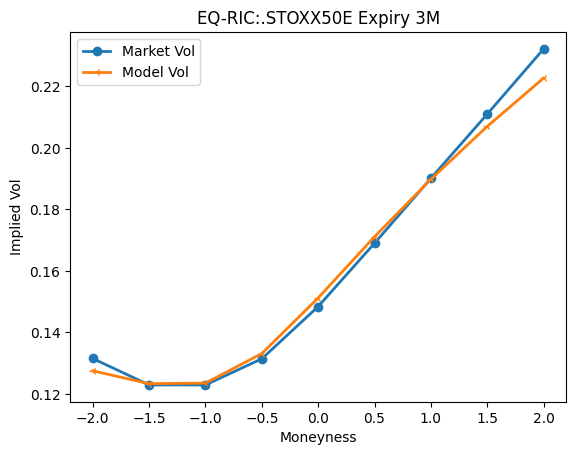

In [5]:
x = df["Moneyness"]
y1 = df["MarketVol"]
y2 = df["ModelVol"]

import matplotlib.pyplot as plt

plt.plot(x, y1, marker="o", linewidth=2, label='Market Vol')
plt.plot(x, y2, marker="3", linewidth=2, label='Model Vol')

plt.xlabel("Moneyness") 
plt.ylabel("Implied Vol") 
plt.title(index + ' Expiry 3M')
plt.legend()

plt.show()